# WikiText-Trained SAE: Cross-Domain Generalization

Encode activations through a SAE trained on Wiki-Text into 8192 sparse features, then train L2-regularised LR on the resulting feature vector. If the SAE basis captures a truth signal/has features that captures "truth", this should result in good performance as the LR model would catch it. 

| # | Probe trains on | Features | Tests on |
|---|----------------|----------|----------|
| 1 | cities | Raw (4096) | FEVER |
| 2 | facts_true_false | Raw (4096) | FEVER |
| 3 | cities | SAE (8192), L2-LR | FEVER |
| 4 | facts_true_false | SAE (8192), L2-LR | FEVER |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression

from utils import collect_acts
from probes import LRProbe

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = 'llama-2-7b'
layer = 12

print(f"Device: {device}")

Device: cpu


---
## Load activations

In [2]:
simple_acts_raw = collect_acts('cities', model, layer, center=False, device=device)
simple_df = pd.read_csv('../datasets/cities.csv')
n_simple = min(simple_acts_raw.shape[0], len(simple_df))
simple_acts_raw = simple_acts_raw[:n_simple]
simple_labels = torch.tensor(simple_df['label'].values[:n_simple], dtype=torch.float32).to(device)

complex_acts_raw = collect_acts('facts_true_false', model, layer, center=False, device=device)
complex_df = pd.read_csv('../datasets/facts_true_false.csv')
n_complex = min(complex_acts_raw.shape[0], len(complex_df))
complex_acts_raw = complex_acts_raw[:n_complex]
complex_labels = torch.tensor(complex_df['label'].values[:n_complex], dtype=torch.float32).to(device)

fever_acts_raw = collect_acts('fever_small', model, layer, center=False, device=device)
fever_df = pd.read_csv('../datasets/fever_small.csv')
n_fever = min(fever_acts_raw.shape[0], len(fever_df))
fever_acts_raw = fever_acts_raw[:n_fever]
fever_labels = torch.tensor(fever_df['label'].values[:n_fever], dtype=torch.float32).to(device)

wikitext_acts_raw = collect_acts('wikitext', model, layer, center=False, device=device)

# Per-dataset centered copies for raw LR baselines
simple_acts_c  = simple_acts_raw  - simple_acts_raw.mean(dim=0)
complex_acts_c = complex_acts_raw - complex_acts_raw.mean(dim=0)
fever_acts_c   = fever_acts_raw   - fever_acts_raw.mean(dim=0)

# Match cities to the size/class balance of facts_true_false for downstream probes only.
target_true = int(complex_labels.sum().item())
target_false = int((1 - complex_labels).sum().item())
true_idx = (simple_labels == 1).nonzero(as_tuple=True)[0]
false_idx = (simple_labels == 0).nonzero(as_tuple=True)[0]
true_perm = true_idx[torch.randperm(len(true_idx))]
false_perm = false_idx[torch.randperm(len(false_idx))]
simple_match_idx = torch.cat([true_perm[:target_true], false_perm[:target_false]])
simple_match_acts_c = simple_acts_c[simple_match_idx]
simple_match_labels = simple_labels[simple_match_idx]

print(f"cities:           {simple_acts_raw.shape}")
print(f"facts_true_false: {complex_acts_raw.shape}")
print(f"FEVER (test):     {fever_acts_raw.shape}")
print(f"WikiText (SAE):   {wikitext_acts_raw.shape}")
print(f"cities matched:   {simple_match_acts_c.shape}  (true: {simple_match_labels.sum().item():.0f}, false: {(1-simple_match_labels).sum().item():.0f})")

cities:           torch.Size([1496, 4096])
facts_true_false: torch.Size([613, 4096])
FEVER (test):     torch.Size([5000, 4096])
WikiText (SAE):   torch.Size([10000, 4096])
cities matched:   torch.Size([613, 4096])  (true: 306, false: 307)


---
## SAE + helpers

In [ ]:
def evaluate(y_true, y_prob):
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    acc = accuracy_score(y_true, (y_prob >= 0.5).astype(int))
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auroc = float('nan')
    return {'accuracy': acc, 'auroc': auroc}


class TopKSparseAutoencoder(nn.Module):
    def __init__(self, input_dim, dict_size, k, ema_decay=0.999, dead_threshold=1e-3):
        super().__init__()
        self.k = k
        self.dict_size = dict_size
        self.encoder = nn.Linear(input_dim, dict_size)
        self.decoder_bias = nn.Parameter(torch.zeros(input_dim))
        nn.init.xavier_uniform_(self.encoder.weight)
        with torch.no_grad():
            self.encoder.weight.div_(self.encoder.weight.norm(dim=1, keepdim=True) + 1e-8)
        self.register_buffer('ema_freq', torch.zeros(dict_size))
        self.ema_decay = ema_decay
        self.dead_threshold = dead_threshold

    def encode(self, x):
        pre = F.relu(self.encoder(x))
        topk_vals, topk_idx = pre.topk(self.k, dim=-1)
        h = torch.zeros_like(pre)
        h.scatter_(1, topk_idx, topk_vals)
        return h

    def decode(self, h):
        return F.linear(h, self.encoder.weight.t(), self.decoder_bias)

    def forward(self, x):
        h = self.encode(x)
        x_hat = self.decode(h)
        if self.training:
            batch_freq = (h > 0).float().mean(dim=0)
            self.ema_freq.mul_(self.ema_decay).add_(batch_freq, alpha=1 - self.ema_decay)
        return x_hat, h

    def aux_dead_loss(self, x, h):
        dead_mask = self.ema_freq < self.dead_threshold
        if not dead_mask.any():
            return torch.tensor(0.0, device=x.device)
        with torch.no_grad():
            residual = x - self.decode(h)
        dead_pre = F.relu(self.encoder(residual))
        dead_acts = dead_pre[:, dead_mask]
        dead_recon = F.linear(dead_acts, self.encoder.weight[dead_mask].t())
        return F.mse_loss(dead_recon, residual)

    def n_dead(self):
        return (self.ema_freq < self.dead_threshold).sum().item()

def train_sae(acts_raw, dict_size=8192, k=64, epochs=300, lr=1e-3,
              batch_size=64, aux_dead_coeff=1/32, print_every=100, device='cpu'):
    acts_np = acts_raw.cpu().numpy() if isinstance(acts_raw, torch.Tensor) else acts_raw
    acts_mean = acts_np.mean(axis=0, keepdims=True)
    acts_std  = acts_np.std(axis=0, keepdims=True) + 1e-6
    acts_scaled = (acts_np - acts_mean) / acts_std

    X_tensor = torch.tensor(acts_scaled, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)

    sae = TopKSparseAutoencoder(input_dim=acts_scaled.shape[1], dict_size=dict_size, k=k).to(device)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)

    for epoch in range(epochs):
        epoch_recon, n_b = 0, 0
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            x_hat, h = sae(x_batch)
            recon_loss = F.mse_loss(x_hat, x_batch)
            total_loss = recon_loss + aux_dead_coeff * sae.aux_dead_loss(x_batch, h)
            opt.zero_grad()
            total_loss.backward()
            opt.step()
            epoch_recon += recon_loss.item()
            n_b += 1
        if (epoch + 1) % print_every == 0:
            print(f"  Epoch {epoch+1:4d} — recon: {epoch_recon/n_b:.4f}, dead: {sae.n_dead()}/{dict_size}")

    return sae, acts_mean, acts_std


def encode_with_sae(sae, acts_raw, acts_mean, acts_std):
    """Encode raw activations to 8192-dim sparse SAE features."""
    acts_np = acts_raw.cpu().numpy() if isinstance(acts_raw, torch.Tensor) else acts_raw
    X = torch.tensor((acts_np - acts_mean) / acts_std, dtype=torch.float32)
    dev = next(sae.parameters()).device
    sae.eval()
    with torch.no_grad():
        return sae.encode(X.to(dev)).cpu().numpy()


def fit_l2_lr(train_X, train_y, test_X, test_y, C_values=(0.01, 0.1, 1.0, 10.0)):
    """Train L2-LR over a C sweep; return best model's train/test metrics and best C."""
    best_auroc, best_res = -1, None
    for C in C_values:
        clf = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=2000, random_state=SEED)
        clf.fit(train_X, train_y)
        tr_prob = clf.predict_proba(train_X)[:, 1]
        te_prob = clf.predict_proba(test_X)[:, 1]
        tr_res = evaluate(train_y, tr_prob)
        te_res = evaluate(test_y, te_prob)
        if tr_res['auroc'] > best_auroc:
            best_auroc = tr_res['auroc']
            best_res = {'train': tr_res, 'test': te_res, 'C': C}
    return best_res


print("SAE + helpers defined.")

SAE + helpers defined.


---
## Run

In [4]:
DICT_SIZE = 8192
K_ACTIVE = 64
WIKITEXT_SAE_N = 3000

torch.manual_seed(SEED)
wikitext_for_sae = wikitext_acts_raw[:WIKITEXT_SAE_N]
print(f"Training WikiText SAE ({wikitext_for_sae.shape[0]} samples, {DICT_SIZE} atoms, k={K_ACTIVE})")
sae_wiki, wiki_mean, wiki_std = train_sae(wikitext_for_sae, dict_size=DICT_SIZE, k=K_ACTIVE, device=device)

# Reconstruction diagnostics
print(f"\nReconstruction MSE:")
for ds_name, ds_acts in [
    ("wikitext (in-domain)", wikitext_acts_raw),
    ("cities",              simple_acts_raw),
    ("facts_true_false",    complex_acts_raw),
    ("FEVER",               fever_acts_raw),
]:
    acts_np = ds_acts.cpu().numpy()
    X = torch.tensor((acts_np - wiki_mean) / wiki_std, dtype=torch.float32).to(device)
    sae_wiki.eval()
    with torch.no_grad():
        x_hat, _ = sae_wiki(X)
        mse = F.mse_loss(x_hat, X).item()
    print(f"  {ds_name:25s}  MSE: {mse:.4f}")

# Encode all datasets through SAE to 8192-dim sparse features
print(f"\nEncoding datasets through SAE...")
simple_sae  = encode_with_sae(sae_wiki, simple_acts_raw,  wiki_mean, wiki_std)
complex_sae = encode_with_sae(sae_wiki, complex_acts_raw, wiki_mean, wiki_std)
fever_sae   = encode_with_sae(sae_wiki, fever_acts_raw,   wiki_mean, wiki_std)

# Downstream probe control: use the matched cities subset without retraining the SAE.
simple_match_sae = simple_sae[simple_match_idx.cpu().numpy()]

print(f"  cities  SAE features:  {simple_sae.shape}  (nnz/row: {(simple_sae > 0).sum(axis=1).mean():.0f})")
print(f"  cities matched SAE:    {simple_match_sae.shape}  (nnz/row: {(simple_match_sae > 0).sum(axis=1).mean():.0f})")
print(f"  facts   SAE features:  {complex_sae.shape}  (nnz/row: {(complex_sae > 0).sum(axis=1).mean():.0f})")
print(f"  FEVER   SAE features:  {fever_sae.shape}  (nnz/row: {(fever_sae > 0).sum(axis=1).mean():.0f})")

Training WikiText SAE (3000 samples, 8192 atoms, k=64)
  Epoch  100 — recon: 1.1528, dead: 844/8192
  Epoch  200 — recon: 13.9446, dead: 410/8192
  Epoch  300 — recon: 0.4144, dead: 64/8192

Reconstruction MSE:
  wikitext (in-domain)       MSE: 2.4368
  cities                     MSE: 1.6818
  facts_true_false           MSE: 1.8696
  FEVER                      MSE: 2.1058

Encoding datasets through SAE...
  cities  SAE features:  (1496, 8192)  (nnz/row: 64)
  cities matched SAE:    (613, 8192)  (nnz/row: 64)
  facts   SAE features:  (613, 8192)  (nnz/row: 64)
  FEVER   SAE features:  (5000, 8192)  (nnz/row: 64)


In [5]:
fever_y = fever_labels.cpu().numpy().astype(int)

# Exp 1–2: LR baselines on raw 4096-dim activations
probe1 = LRProbe.from_data(simple_match_acts_c, simple_match_labels, device=device)
with torch.no_grad():
    exp1_train = evaluate(simple_match_labels.cpu().numpy(), probe1(simple_match_acts_c).cpu().numpy())
    exp1_test  = evaluate(fever_y, probe1(fever_acts_c).cpu().numpy())

probe2 = LRProbe.from_data(complex_acts_c, complex_labels, device=device)
with torch.no_grad():
    exp2_train = evaluate(complex_labels.cpu().numpy(), probe2(complex_acts_c).cpu().numpy())
    exp2_test  = evaluate(fever_y, probe2(fever_acts_c).cpu().numpy())

print(f"Exp 1 (LR raw, cities):  train acc {exp1_train['accuracy']:.4f}  |  FEVER acc {exp1_test['accuracy']:.4f}  AUROC {exp1_test['auroc']:.4f}")
print(f"Exp 2 (LR raw, facts):   train acc {exp2_train['accuracy']:.4f}  |  FEVER acc {exp2_test['accuracy']:.4f}  AUROC {exp2_test['auroc']:.4f}")

# Exp 3–4: L2-LR on full 8192-dim SAE features
simple_match_y = simple_match_labels.cpu().numpy().astype(int)
complex_y = complex_labels.cpu().numpy().astype(int)

exp3 = fit_l2_lr(simple_match_sae, simple_match_y, fever_sae, fever_y)
exp4 = fit_l2_lr(complex_sae, complex_y, fever_sae, fever_y)

print(f"Exp 3 (SAE+L2-LR, cities, C={exp3['C']}):  train acc {exp3['train']['accuracy']:.4f}  |  FEVER acc {exp3['test']['accuracy']:.4f}  AUROC {exp3['test']['auroc']:.4f}")
print(f"Exp 4 (SAE+L2-LR, facts,  C={exp4['C']}):  train acc {exp4['train']['accuracy']:.4f}  |  FEVER acc {exp4['test']['accuracy']:.4f}  AUROC {exp4['test']['auroc']:.4f}")

Exp 1 (LR raw, cities):  train acc 0.9967  |  FEVER acc 0.6176  AUROC 0.6590
Exp 2 (LR raw, facts):   train acc 0.9364  |  FEVER acc 0.6782  AUROC 0.7259
Exp 3 (SAE+L2-LR, cities, C=10.0):  train acc 0.9527  |  FEVER acc 0.5430  AUROC 0.5625
Exp 4 (SAE+L2-LR, facts,  C=10.0):  train acc 0.7961  |  FEVER acc 0.5348  AUROC 0.5734


---
## Results

In [6]:
results = {
    'LR raw, cities':                            {'train': exp1_train, 'test': exp1_test},
    'LR raw, facts':                             {'train': exp2_train, 'test': exp2_test},
    f'SAE+L2-LR (C={exp3["C"]}), cities':        {'train': exp3['train'], 'test': exp3['test']},
    f'SAE+L2-LR (C={exp4["C"]}), facts':         {'train': exp4['train'], 'test': exp4['test']},
}

rows = []
for name, res in results.items():
    rows.append({
        'Experiment': name,
        'Train Acc': res['train']['accuracy'],
        'FEVER Acc': res['test']['accuracy'],
        'FEVER AUROC': res['test']['auroc'],
    })

print(pd.DataFrame(rows).to_string(index=False, float_format='%.4f'))

                Experiment  Train Acc  FEVER Acc  FEVER AUROC
            LR raw, cities     0.9967     0.6176       0.6590
             LR raw, facts     0.9364     0.6782       0.7259
SAE+L2-LR (C=10.0), cities     0.9527     0.5430       0.5625
 SAE+L2-LR (C=10.0), facts     0.7961     0.5348       0.5734


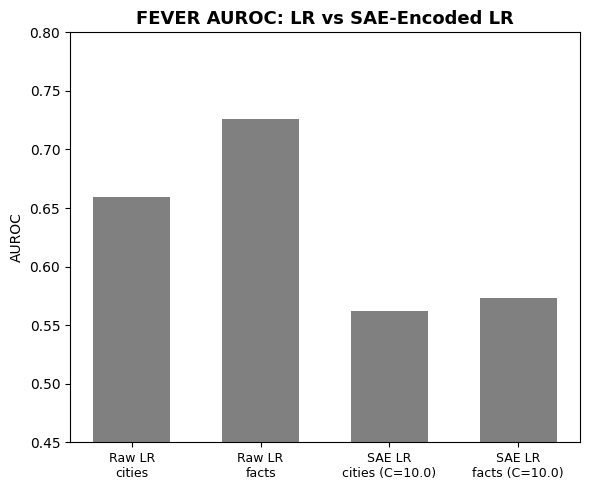

In [7]:
# Visualize

exp_labels = [
    'Raw LR\ncities',
    'Raw LR\nfacts',
    f'SAE LR\ncities (C={exp3["C"]})',
    f'SAE LR\nfacts (C={exp4["C"]})',
]

test_aurocs = [r['test']['auroc'] for r in results.values()]

fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(len(exp_labels))
width = 0.6
ax.bar(x, test_aurocs, width, color='gray')

ax.set_ylabel('AUROC')
ax.set_title('FEVER AUROC: LR vs SAE-Encoded LR', fontsize=13, fontweight='bold')
ax.set_ylim(0.45, 0.8)
ax.set_xticks(x)
ax.set_xticklabels(exp_labels, fontsize=9)
# ax.axhline(0.5, color='gray', ls='--', lw=0.8, label='chance')

plt.tight_layout()
plt.show()